# Лабораторная работа 4. Кластеризация

## Цель работы:
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качества.

## Датасет
**Источник:** [Flower Classification](https://www.kaggle.com/datasets/tusharkute/flower-classification)

## Описание
Этот набор данных представляет собой синтетическую коллекцию из 50 записей, разработанную для практики и изучения многоклассовой классификации. Он посвящен четырем распространённым типам цветов: роза, жасмин, бархатцы и гибискус. Данные содержат количественные морфологические и цветовые признаки, которые можно использовать для различения этих видов. 

**Основные характеристики:**
- Подходит для обучения - изучения основ классификации и кластеризации
- Объем данных: 50 наблюдений
- Количество признаков: 11


## Описание переменных датасета

| Переменная                  | Описание                                                                  |
| --------------------------- | ------------------------------------------------------------------------- |
| **ID**                      | Уникальный идентификатор для каждой записи о цветке                       |
| **Flower Type**             | Тип цветка (Rose, Jasmine, Marigold, Hibiscus)                            |
| **Sepal Length (cm)**       | Длина чашелистика в сантиметрах                                           |
| **Petal Length (cm)**       | Длина лепестка в сантиметрах                                              |
| **Sepal Width (cm)**        | Ширина чашелистика в сантиметрах                                          |
| **Petal Width (cm)**        | Ширина лепестка в сантиметрах                                             |
| **Flower Radius (cm)**      | Радиус цветка в сантиметрах                                               |
| **Number of Petals/Sepals** | Количество лепестков или чашелистиков (в зависимости от структуры цветка) |
| **Avg_R**                   | Среднее значение красного канала (0–255) для доминирующего цвета          |
| **Avg_G**                   | Среднее значение зелёного канала (0–255) для доминирующего цвета          |
| **Avg_B**                   | Среднее значение синего канала (0–255) для доминирующего цвета            |


In [208]:
#python -m pip install matplotlib pandas scikit-learn seaborn jupyter numpy ipykernel
 

In [2]:
# # Импорт библиотек
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis, kstest


## 1. Загрузка датасета. Первичный анализ

In [309]:
# Чтение данных из файла в датафрейм. Настройки
path = 'flower-classification.csv'
#target = 'DEATH_EVENT'

# Дескриптивный анализ столбцов
pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv(path)
df.info()
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       50 non-null     int64  
 1   Flower Type              50 non-null     object 
 2   Sepal Length (cm)        50 non-null     float64
 3   Petal Length (cm)        50 non-null     float64
 4   Sepal Width (cm)         50 non-null     float64
 5   Petal Width (cm)         50 non-null     float64
 6   Flower Radius (cm)       50 non-null     float64
 7   Number of Petals/Sepals  50 non-null     int64  
 8   Avg_R                    50 non-null     int64  
 9   Avg_G                    50 non-null     int64  
 10  Avg_B                    50 non-null     int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 4.4+ KB
         ID  Sepal Length (cm)  Petal Length (cm)  Sepal Width (cm)  \
count 50.00              50.00              50.00             

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sepal Length (cm)        50 non-null     float64
 1   Petal Length (cm)        50 non-null     float64
 2   Sepal Width (cm)         50 non-null     float64
 3   Petal Width (cm)         50 non-null     float64
 4   Flower Radius (cm)       50 non-null     float64
 5   Number of Petals/Sepals  50 non-null     int64  
 6   Avg_R                    50 non-null     int64  
 7   Avg_G                    50 non-null     int64  
 8   Avg_B                    50 non-null     int64  
dtypes: float64(5), int64(4)
memory usage: 3.6 KB


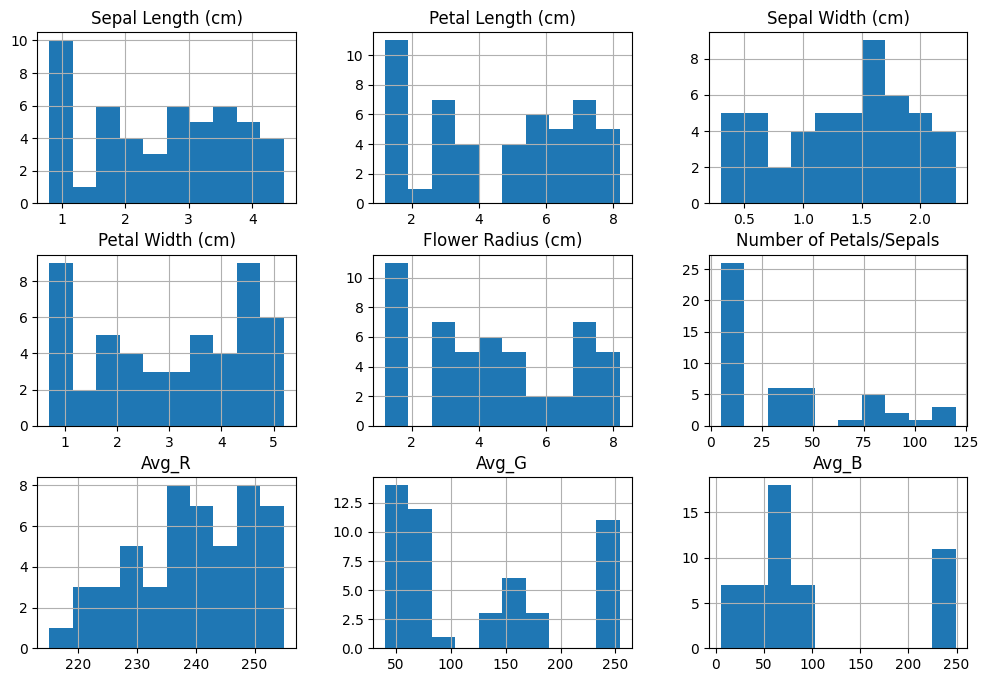

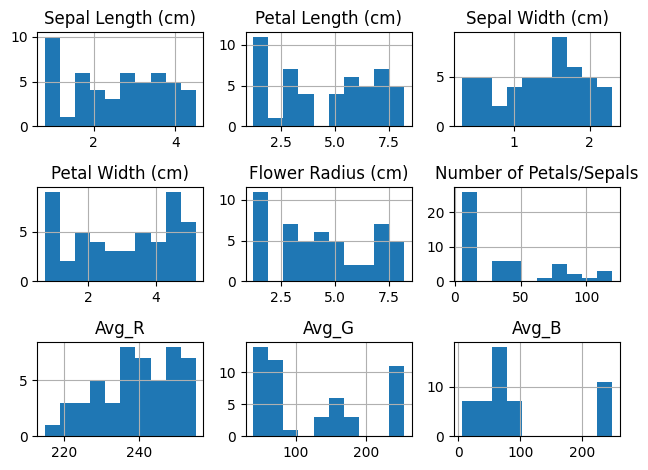

In [310]:
# Визуализация признаков и целевой переменной

#df['Sex'] = df['Gender_Code'].map({'Male': 0, 'Female': 1})
#df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
# df['CAECn'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always' : 3})
# df['CALCn'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always' : 3})
# df['MTRANSn'] = df['MTRANS'].map({'Walking': 0, 'Bike': 1, 'Motorbike': 2, 'Public_Transportation' : 3})
# df = df.replace({'yes': 1, 'no': 0})

#df['Sex'] = df['gender'].map({'Male': 0, 'Female': 1})
drop_columns = ['Gender', 'CAEC', 'CALC', 'Obesity', 'MTRANS',  'assignments_submitted', 'name', 'gender', 'student_id', 'total_assignments', 'total_lectures', 'total_lab_sessions',  
                'Date', 'cluster', 'city_name', 'country', 'ID', 'Flower Type', 'key', 'name', 'image', 'splash', 'criticalStrikeChance','criticalStrikeChancePerLevel',
                 'InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'CustomerID', 'Country', 'id', 'Flower Type'
                ] # Ненужные столбцы


#df['region_encoded'], uniques = pd.factorize(df['Region'])

y_true, uniques = pd.factorize(df['Flower Type'])

df.drop(drop_columns, axis=1, errors='ignore', inplace=True)


df = df.dropna()

numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns.tolist()]
df = df[numeric_features]

df.info()
df.hist(figsize=(12,8))
df.hist()
plt.tight_layout()
plt.show()


### Визуальный анализ: построение гистограмм, проверка на нормальность, проверка мультиколлинеарности, построение ящиков с усами.

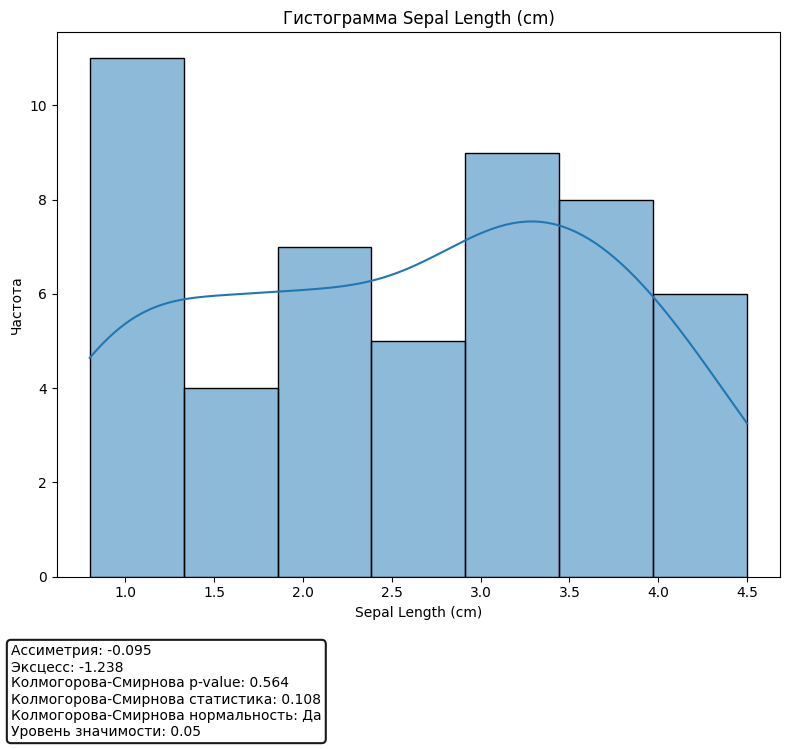

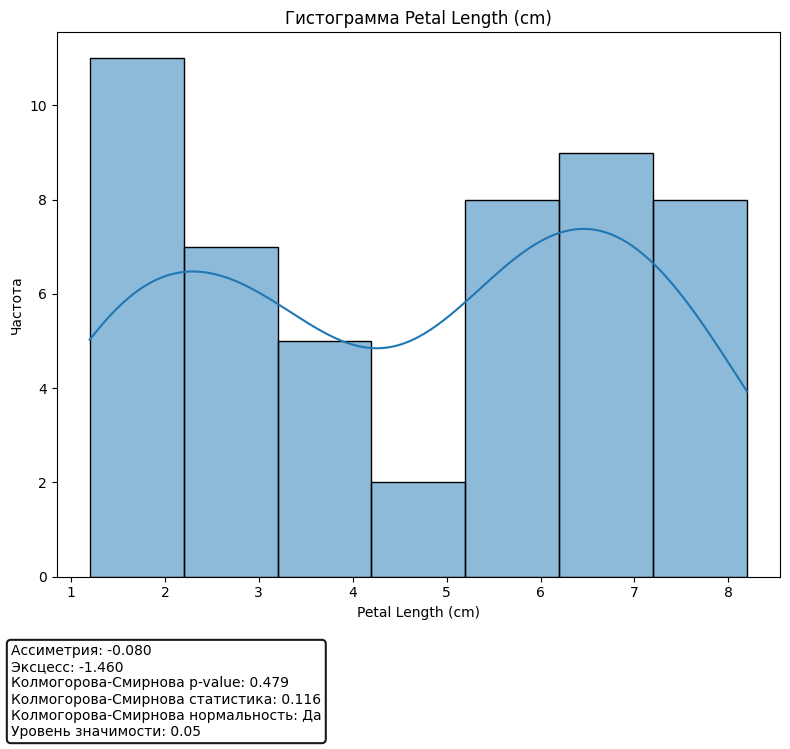

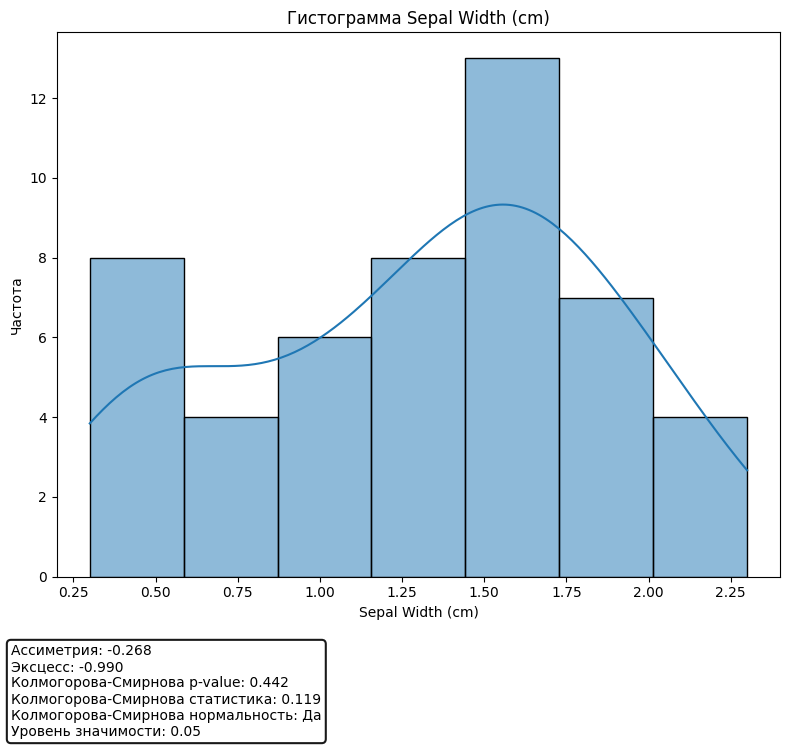

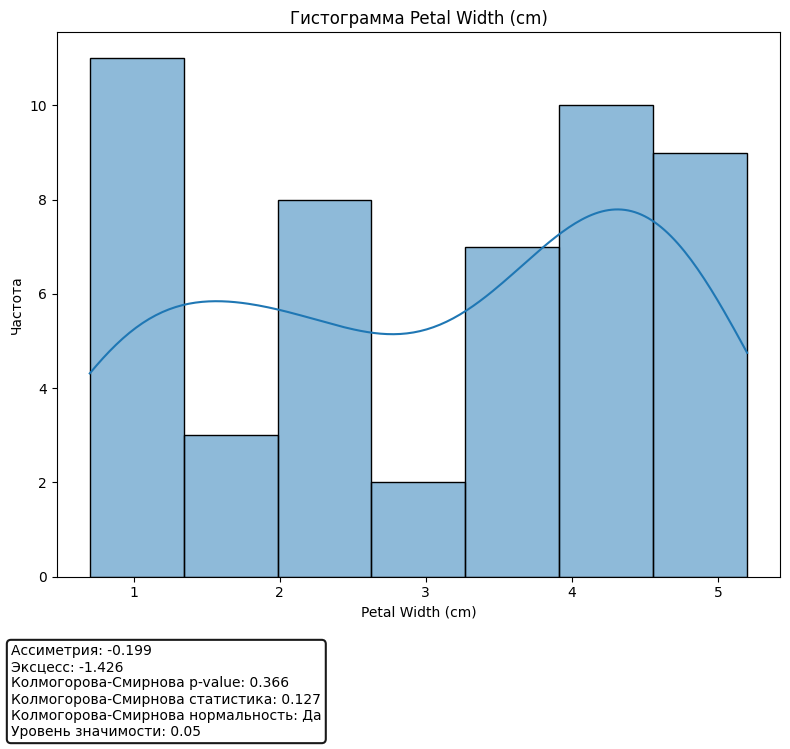

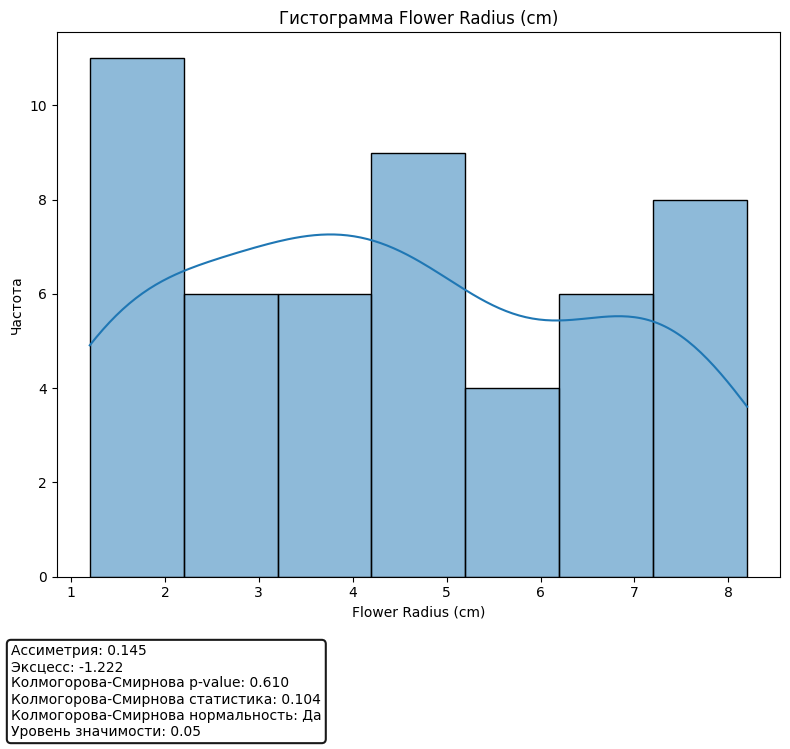

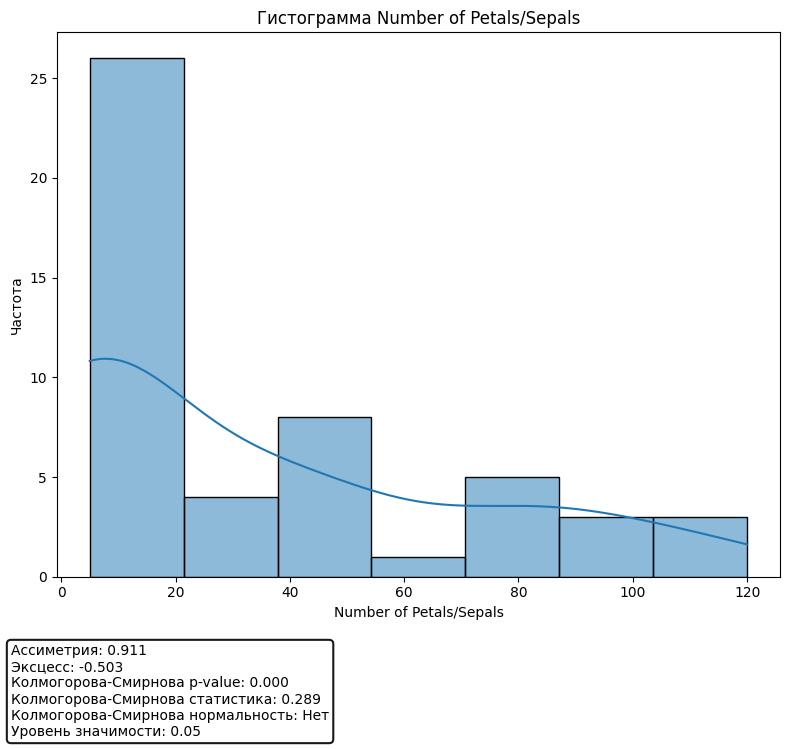

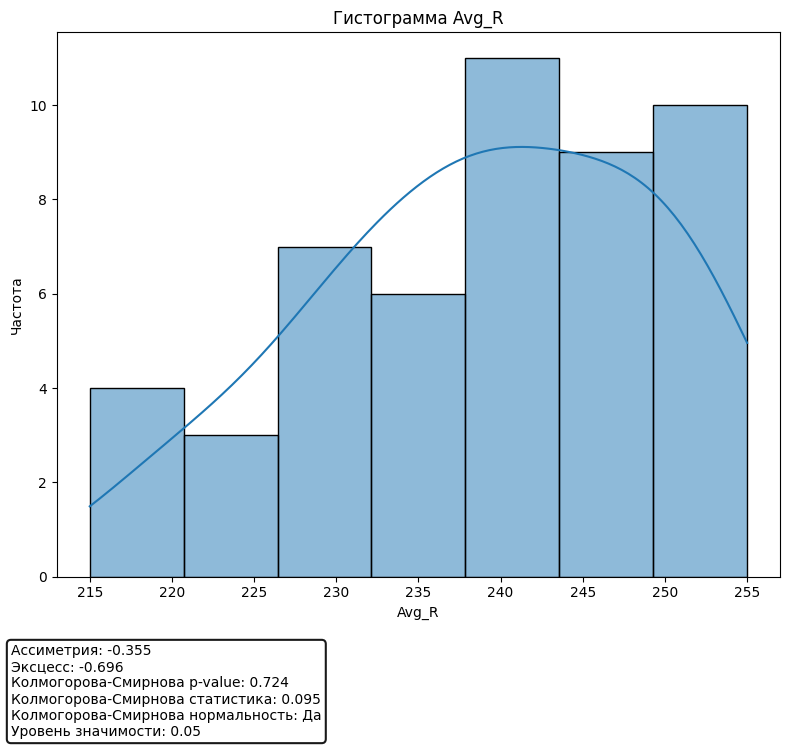

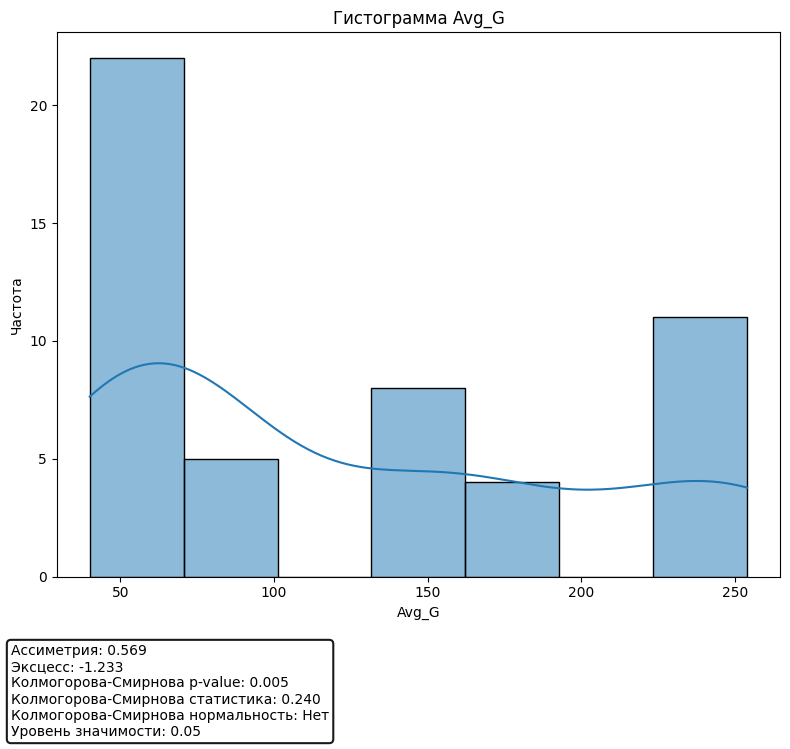

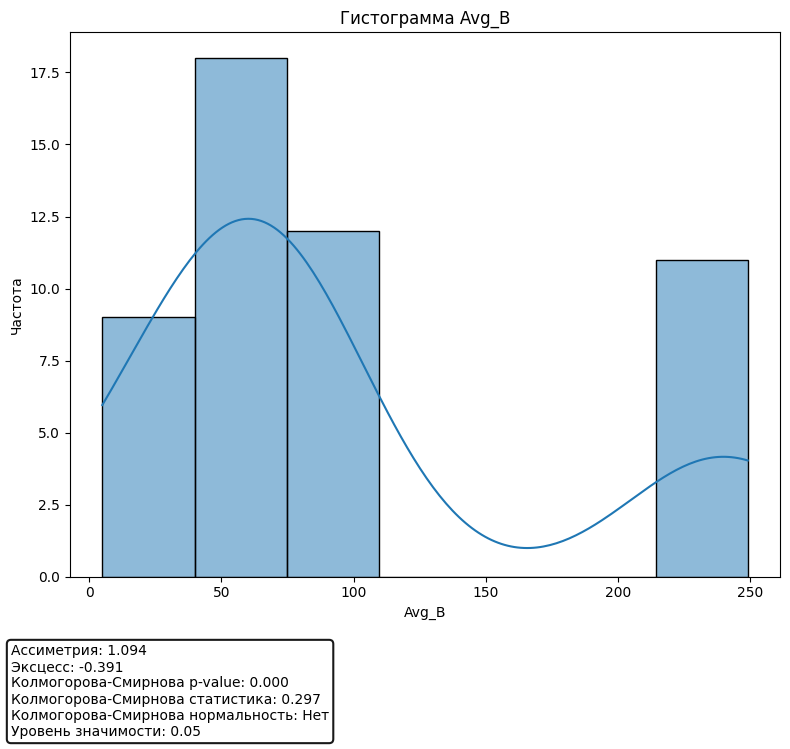

In [312]:
# Проверка распределений на нормальность
ALPHA = 0.05
for _, column in enumerate(df.columns):
    plt.figure(figsize=(8, 8))
    sns.histplot(df[column], kde=True, bins='sturges')

    ks_stat, ks_p_value = kstest(df[column], 'norm', args=(np.mean(df[column]), np.std(df[column])))

    legend = (
        f'Ассиметрия: {skew(df[column]):.3f}\n'
        f'Эксцесс: {kurtosis(df[column]):.3f}\n'
        f'Колмогорова-Смирнова p-value: {(ks_p_value):.3f}\n'
        f'Колмогорова-Смирнова статистика: {(ks_stat):.3f}\n'
        f'Колмогорова-Смирнова нормальность: {'Да' if ks_p_value >= ALPHA else 'Нет'}\n'
        f'Уровень значимости: {ALPHA}'
    )

    plt.figtext(
        0.02, 
        0.02, 
        legend, 
        ha='left', 
        va='bottom', 
        fontsize=10, 
        bbox=dict(
            boxstyle='round', 
            facecolor='white', 
            edgecolor='black',
            linewidth=1.5,
            alpha=0.9
        )
    )

    # print(column)
    # print(50 * '-')
    # print(legend)
    # print(50 * '=')
    # print()

    plt.title(f'Гистограмма {column}')
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.tight_layout(rect=[0, 0.15, 1, 0.95])

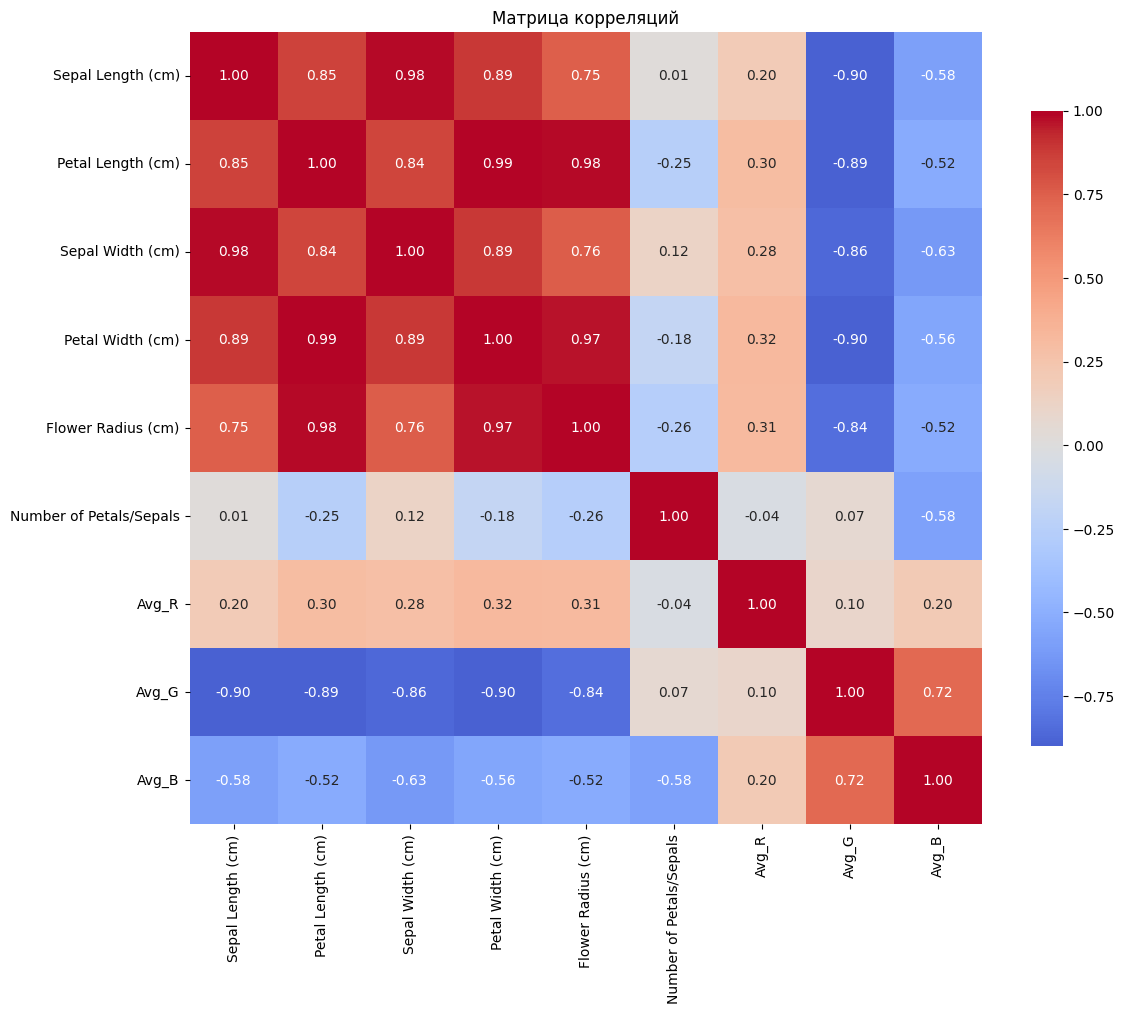

Коэффициенты корреляции для целевой переменной:
                          Sepal Length (cm)  Petal Length (cm)  \
Sepal Length (cm)                     1.00               0.85   
Petal Length (cm)                     0.85               1.00   
Sepal Width (cm)                      0.98               0.84   
Petal Width (cm)                      0.89               0.99   
Flower Radius (cm)                    0.75               0.98   
Number of Petals/Sepals               0.01              -0.25   
Avg_R                                 0.20               0.30   
Avg_G                                -0.90              -0.89   
Avg_B                                -0.58              -0.52   

                         Sepal Width (cm)  Petal Width (cm)  \
Sepal Length (cm)                    0.98              0.89   
Petal Length (cm)                    0.84              0.99   
Sepal Width (cm)                     1.00              0.89   
Petal Width (cm)                     0.89       

In [313]:
# Составление матрицы корреляций и тепловой карты
correlation_matrix = df.corr(method='pearson')

plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': .8})

plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

#correlation_val = correlation_matrix[target].sort_values(ascending=False)
print('Коэффициенты корреляции для целевой переменной:\n',correlation_matrix)

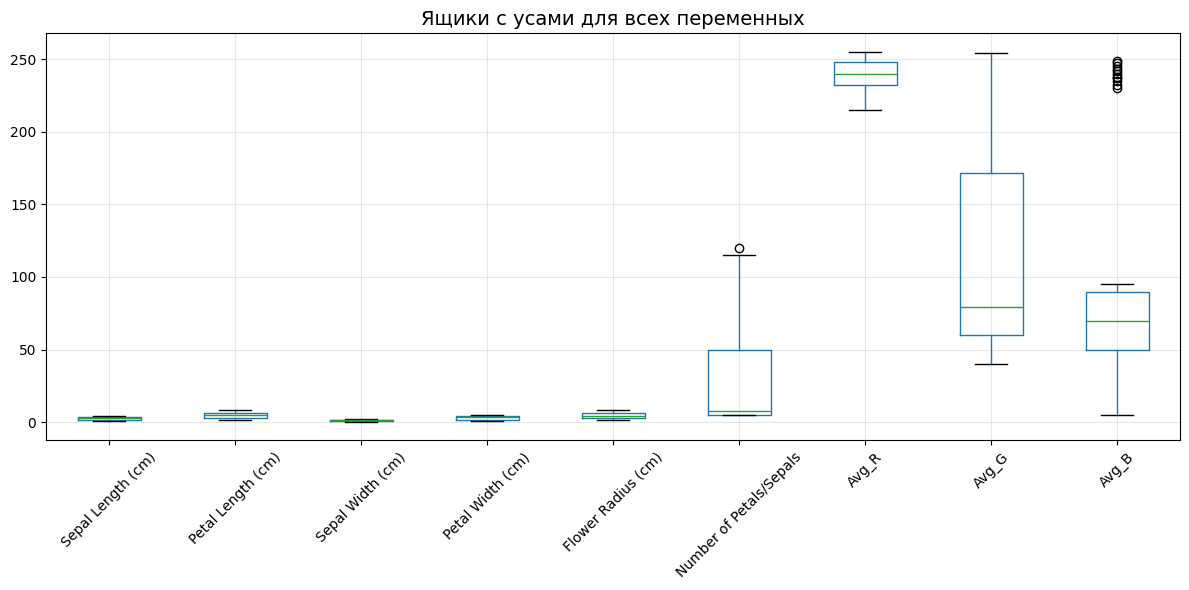

In [314]:
plt.figure(figsize=(12, 6))
df.boxplot()
plt.title('Ящики с усами для всех переменных', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Данные были загружены, пропусков нет, все переменные имеют числовые типы, за исключением перменной Flower Type, представляющией собой название цветка (его класс).
Переменные ID (уникальный идентификатор цветка) и Flower Type (вид цветка) можно удалить, т.к. в задаче кластеризации они не имеют смысла. Предполагается, что предварительно нас не интересует количество и принадлежность цветов к какому-либо классу, а также их идентификатор. 

Следующие переменные имеют минимальное отколонение от нормального распределения:
- Sepal Length (cm)

- Petal Length (cm)

- Sepal Width (cm)

- Petal Width (cm)

- Flower Radius (cm)

- Avg_R

Распределение остальных переменных не является нормальным:
- Number of Petals/Sepals

- Avg_G

- Avg_B

Такой результат вероятно обусловлен малым размером выборки и синтетической природой исходных данных.

На основе матрицы корреляций признаков можно сделать следующие выводы:
1. Размерные признаки цветка (длина/ширина/радиус) очень сильно коррелируют между собой. Признак Flower Radius почти заменяет все остальные.
2. Цвет по зелёному цветовому каналу (Avg_G) сильно связан с размерами: чем меньше цветок, тем он зеленее
3. Синий цветовой канал также отрицательно связан с размерами, но слабее
4. Красный цветовой канал почти не несёт связанной информации
5. Количество лепестков - независим от остальных фактор
6. У переменной Avg_B (синий цветовой канал) имеется сильная корреляция с другими переменными
7. Переменные Petal Length (cm), Sepal Width (cm), Petal Width (cm), Flower Radius (cm), Avg_G, Avg_B имеют сильную корреляцию

По ящикам с усами можно увидеть, что диапазон значений у переменных сильно отличается, у переменной Avg_B (синий цветовой канал) очень много выбросов, переменная Number of Petals/Sepals также имеет выброс. 

Для задачи кластеризации необходима стандартизация и удаление сильнокоррелирующих признаков. 

## 2. Подготовка данных к кластеризации: устранение мультиколлинеарности, стандартизация переменных


Для данных распределенных нормально будем использовать StandartScaler, так как он сохраняет структуру данных, взаимные расстояния, не искажает корреляции.
Для данных распределенных иным образом будем использовать PowerTransformer, так как он преобразует данные так, чтобы распределение становилось ближе к нормальному, уменьшает ассиметрию, исправляет эксцесс.

#### Стандартизация признаков

In [315]:
import numpy as np
import pandas as pd
from scipy.stats import kstest
from sklearn.preprocessing import StandardScaler, PowerTransformer

ALPHA = 0.05  # уровень значимости для теста нормальности


df = df.copy()
df.dropna(inplace=True)

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

normal_cols = []
nonnormal_cols = []


for col in numeric_features:
    stat, p = kstest(df[col], 'norm', args=(df[col].mean(), df[col].std()))
    if p >= ALPHA:
        normal_cols.append(col)
    else:
        nonnormal_cols.append(col)

print("Нормальные признаки:", normal_cols)
print("Ненормальные признаки:", nonnormal_cols)

scaler_standard = StandardScaler()
scaled_normal = scaler_standard.fit_transform(df[normal_cols])
scaled_normal_df = pd.DataFrame(scaled_normal, columns=normal_cols, index=df.index)

scaler_power = PowerTransformer(method='yeo-johnson')
scaled_nonnormal = scaler_power.fit_transform(df[nonnormal_cols])
scaled_nonnormal_df = pd.DataFrame(scaled_nonnormal, columns=nonnormal_cols, index=df.index)

scaled_df = pd.concat([scaled_normal_df, scaled_nonnormal_df], axis=1)

print("\nДескриптивный анализ после трансформации:")
print(scaled_df.describe())


Нормальные признаки: ['Sepal Length (cm)', 'Petal Length (cm)', 'Sepal Width (cm)', 'Petal Width (cm)', 'Flower Radius (cm)', 'Avg_R']
Ненормальные признаки: ['Number of Petals/Sepals', 'Avg_G', 'Avg_B']

Дескриптивный анализ после трансформации:
       Sepal Length (cm)  Petal Length (cm)  Sepal Width (cm)  \
count              50.00              50.00             50.00   
mean                0.00              -0.00              0.00   
std                 1.01               1.01              1.01   
min                -1.57              -1.49             -1.80   
25%                -0.75              -0.86             -0.72   
50%                 0.16               0.25              0.18   
75%                 0.82               0.84              0.72   
max                 1.71               1.59              1.80   

       Petal Width (cm)  Flower Radius (cm)  Avg_R  Number of Petals/Sepals  \
count             50.00               50.00  50.00                    50.00   
mean     

#### Удаление ненужных признаков после анализа корреляции и ящиков с усами

In [318]:
drop_columns = ['Petal Width (cm)', 'Avg_B', 'Sepal Width (cm)', 'Avg_G', 'Flower Radius (cm)', 'Petal Length (cm)'] # Ненужные столбцы
scaled_df.drop(drop_columns, axis=1, errors='ignore', inplace=True) # Удаление столбцов


#### Матрица корреляций после удаления переменных с высокой корреляцией и выбросами

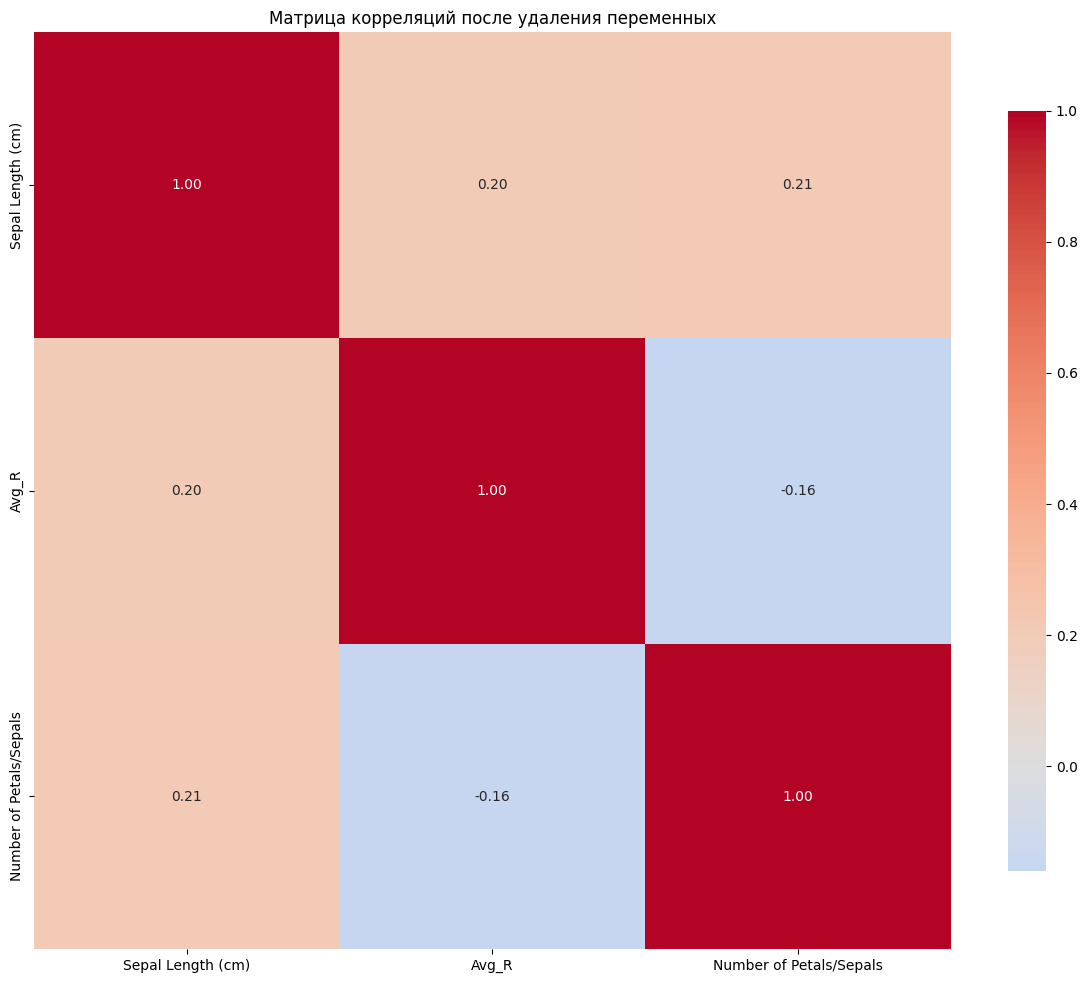

In [317]:
correlation_matrix = scaled_df.corr(method='pearson')

plt.figure(figsize=(12, 10))

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': .8})

plt.title('Матрица корреляций после удаления переменных')
plt.tight_layout()
plt.show()

#### Ящики с усами по оставшимся признакам

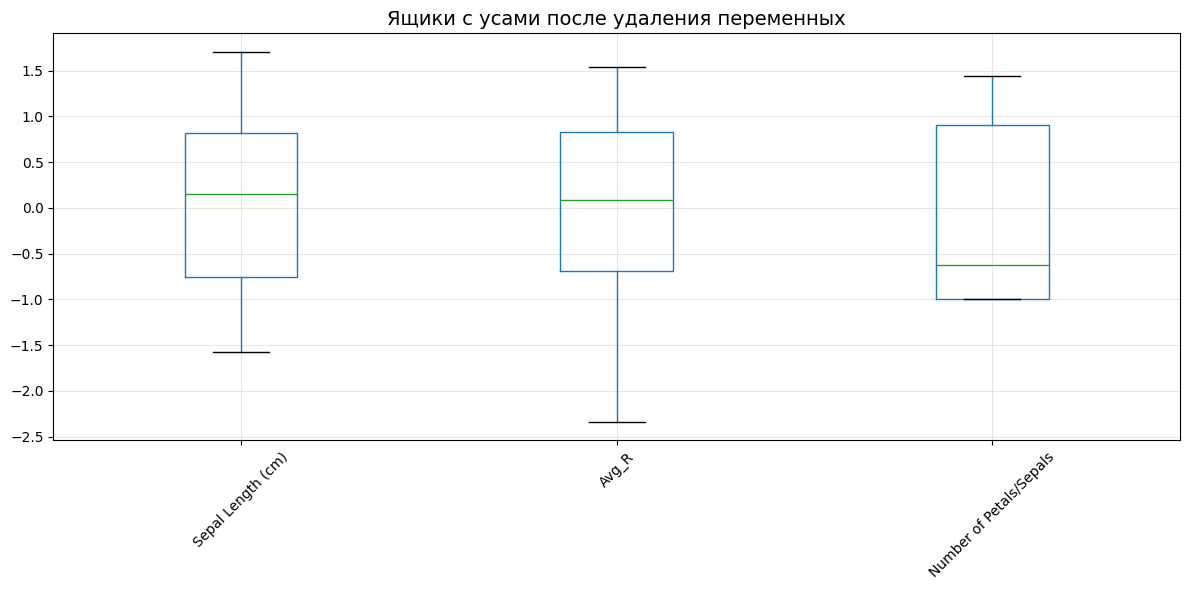

In [319]:
plt.figure(figsize=(12, 6))
scaled_df.boxplot()
plt.title('Ящики с усами после удаления переменных', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Матрица диаграмм рассеивания

<Figure size 1200x1000 with 0 Axes>

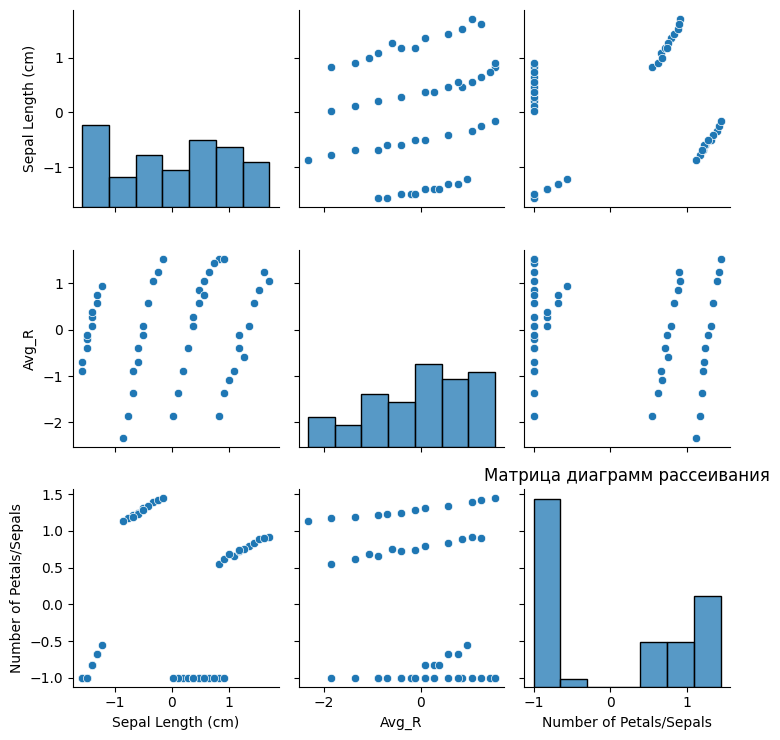

In [320]:
# Матрица диаграмм рассеивания
plt.figure(figsize=(12, 10))

sns.pairplot(scaled_df)

plt.title('Матрица диаграмм рассеивания')
plt.tight_layout()
plt.show()

Видно, что остались признаки со слабой взаимной корреляцией, что удовлетворяет условиям решения задачи кластеризации. В результате стандартизации признаков все выбросы были устранены.

По матрице диаграмм ресяния можно увидеть, что точки на осях разбиваются на вытянутые группы (то есть прямые из точек) зачастую не очень плотные. Предварительно данные можно разделить на 3-4 группы. Размеры кластеров примерно одинаковые. В осях Avg_R - Number of Petals/Sepals присутствуют наложения либо слияния кластеров в один.

Метод K-means более ориентирован на сферические (выпуклые) кластеры, в данном случае он не подходит, т.к. кластеры имеют вытянутую форму.\
Метод DBSCAN не подходит, т.к. кластеры небольшие и имеют вытянутую форму с не очень большой плотностью. Предположительно многие точки могут быть приняты за шум.

На основании анализа были выбраны следующие методы кластеризации:
- EM-алгоритм (Gaussian Mixture), т.к. переменные стандартизированы и практически привидены к нормальным распределениям.
- Иерархическая кластеризация, т.к. датасет небольшой и данный метод хорошо работает с вытянутыми кластерами.


## 3. Реализация кластеризации методами Gaussian Mixture и Иерархической кластеризации

#### GMM

Для реализации метода GMM (Gaussian mixture) необходимо предварительно найти оптимальное количество кластеров k.\
Сделаем это с помощью метода локтя и анализа силуэта.

Графики локтя строятся по информационным критериям AIC и BIC
AIC - Фокусируется на прогнозной способности, лучше	когда цель - предсказание новых данных
BIC - Фокусируется на нахождении "истинной" модели, лучше, когда цель - объяснение и изучение теории

Определение оптимального количества кластеров аналогично методу локтя - ищем точку, после которой улучшение критерия становится незначительным

На графике силуэта берем точку с максимальным значением коэфициента силуэта

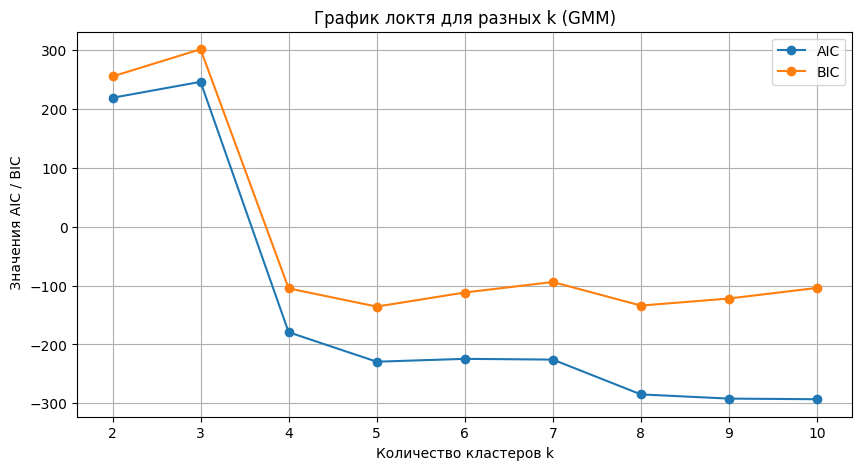

In [322]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

K = range(2, 11)
aic_scores = []
bic_scores = []

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=43)
    gmm.fit(scaled_df)
    
    aic_scores.append(gmm.aic(scaled_df))
    bic_scores.append(gmm.bic(scaled_df))

# График AIC/BIC
plt.figure(figsize=(10,5))

plt.plot(K, aic_scores, '-o', label='AIC')
plt.plot(K, bic_scores, '-o', label='BIC')

plt.title('График локтя для разных k (GMM)')
plt.xlabel('Количество кластеров k')
plt.ylabel(' Значения AIC / BIC')
plt.xticks(K)
plt.grid(True)
plt.legend()
plt.show()


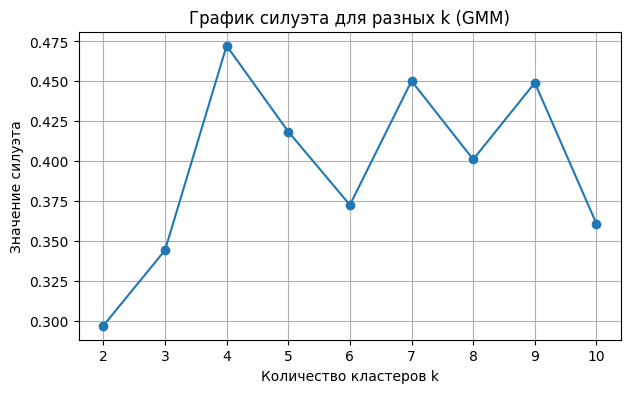

In [323]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

K = range(2, 11) 
sil_scores = []

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=43)
    labels = gmm.fit_predict(scaled_df)
    sil = silhouette_score(scaled_df, labels)
    sil_scores.append(sil)


# График силуэта
plt.figure(figsize=(7,4))
plt.plot(K, sil_scores, '-o')

plt.title('График силуэта для разных k (GMM)')
plt.xlabel('Количество кластеров k')
plt.ylabel('Значение силуэта')
plt.grid(True)
plt.show()


#### По результатам графиков локтя и силуэта для GMM, оптимальное количество кластеров K = 4

In [324]:
gmm_clusters = GaussianMixture(n_components=4, random_state=43)
gmm_labels = gmm_clusters.fit_predict(scaled_df)

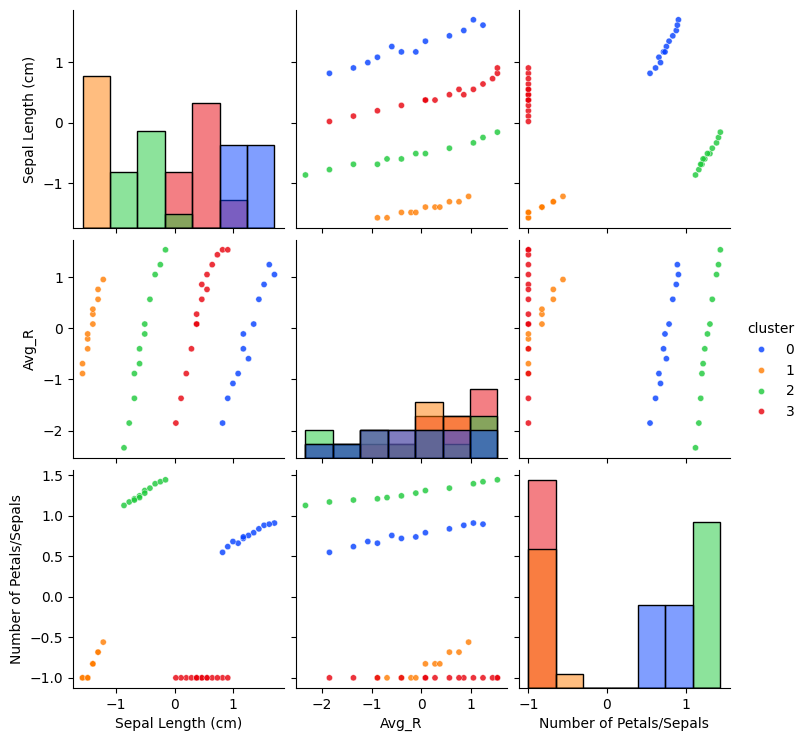

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = gmm_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

In [326]:
import numpy as np
from itertools import combinations

def jaccard_index_pairs(y_true, y_pred):
    n = len(y_true)

    M11 = M10 = M01 = 0

    for i, j in combinations(range(n), 2):
        same_true = (y_true[i] == y_true[j])
        same_pred = (y_pred[i] == y_pred[j])

        if same_true and same_pred:
            M11 += 1
        elif same_true and not same_pred:
            M10 += 1
        elif not same_true and same_pred:
            M01 += 1

    return M11 / (M11 + M10 + M01)

In [327]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики
print("Silhouette:", silhouette_score(scaled_df, gmm_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, gmm_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, gmm_labels))

# Внешние метрики 
print("Adjusted Rand Index:", adjusted_rand_score(y_true, gmm_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, gmm_labels))

# Индекс Джакара
jaccard = jaccard_index_pairs(y_true, gmm_labels)
print("Jaccard Index:", jaccard)

Silhouette: 0.47232898626350867
Calinski-Harabasz: 30.77204216129424
Davies-Bouldin: 0.9021698194196958
Adjusted Rand Index: 1.0
Fowlkes-Mallows Index: 1.0
Jaccard Index: 1.0


Была произведена кластеризация методом GMM и на основе анализа полученных диаграмм рассеяния и метрик качества получены следующие выводы:
- По графикам рассеяния видно, что произошло четкое разбиение на кластеры в осях Sepal Length (cm) - Avg_R, Avg_R - Sepal Length (cm), Sepal Length (cm) - Number of Petals\Sepals. 
- В осях Avg_R - Number of Petals/Sepals, Number of Petals/Sepals - Avg_R имеется небольшое наложение кластеров 1 и 3.
- Распределение Avg_R по кластером плохо

Внутренние метрики валидации:
- Silhouette Score = 0.472 - хорошее качество кластеризации, кластеры достаточно компактны и хорошо разделены
- Calinski-Harabasz = 30.77 - высокое отношение межкластерной дисперсии к внутрикластерной, кластеры плотные и четко отделены друг от друга
- Davies-Bouldin = 0.902 - минимальное перекрытие между кластерами (чем ближе к 1, тем лучше)

Внешние метрики валидации:
- Adjusted Rand Index, Fowlkes-Mallows Index, Jaccard Index все равны 1, что говорит о полном совпадении с изначальными классами




#### Иерархическая кластеризация

Для иерархической кластеризации также необходимо найти оптимальное количество кластеров k.

Делать это можно с помощью графика силуэта и дендрограммы.

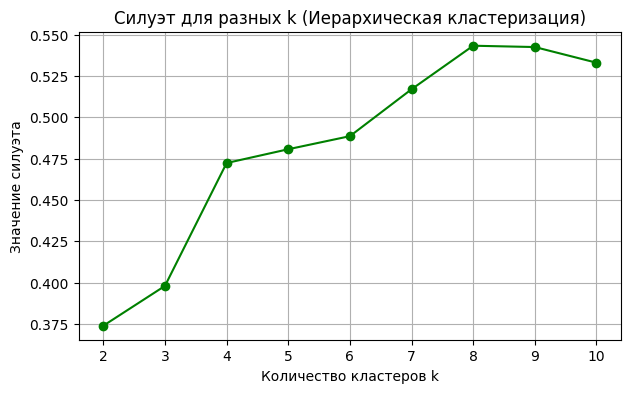

In [328]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

K = range(2, 11)
sil_scores = []

for k in K:
    hier = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier.fit_predict(scaled_df)
    sil = silhouette_score(scaled_df, labels)
    sil_scores.append(sil)


plt.figure(figsize=(7,4))
plt.plot(K, sil_scores, '-o', color='green')
plt.title('Силуэт для разных k (Иерархическая кластеризация)')
plt.xlabel('Количество кластеров k')
plt.ylabel('Значение силуэта')
plt.grid(True)
plt.show()

#### По результатам графика силуэта для иерархической кластеризации оптимальное количество кластеров k = 8

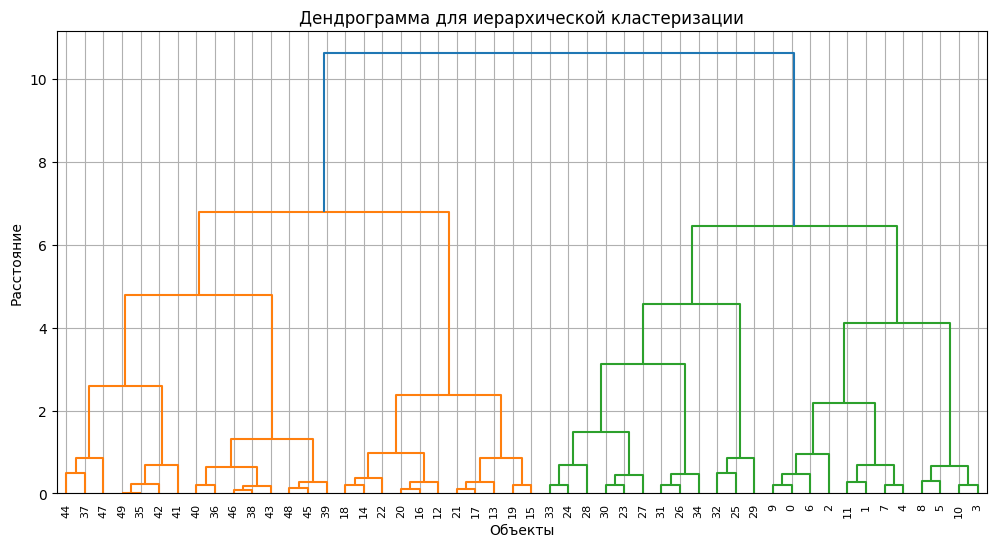

In [329]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


linked = linkage(scaled_df, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False
)
plt.title("Дендрограмма для иерархической кластеризации")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")
plt.grid(True)
plt.show()

На основе анализа дендрограммы можно сделать следующие выводы:

- Наибольший разрыв в вертикальном направлении происходит примерно на уровне 6–7.

- Левая часть дерева объединяет несколько объектов, которые слиты на низких уровнях - эти объекты очень похожи

- Правая часть дерева также содержит несколько подкластеров, которые объединяются постепенно - здесь тоже можно выделить внутренние группы

- Небольшие вертикальные внутри крупных ветвей говорят о том, что объекты внутри этих кластеров похожи друг на друга (малое расстояние слияния)

- Большие вертикальные скачки при объединении двух крупных ветвей говорят о существенном различии между кластерами

Дендрограмма говорит о том, что можно выбрать подкластеры в пределах каждой основной ветви - примерно 4-5 кластеров

#### Метод локтя показал оптимальное количество кластеров для иерархической кластеризации 8, а дерево дендрограммы 4-5. Возьмем среднее значение k = 6.

In [330]:
hier_final = AgglomerativeClustering(n_clusters=6, linkage='ward')
hier_final_labels = hier_final.fit_predict(scaled_df)

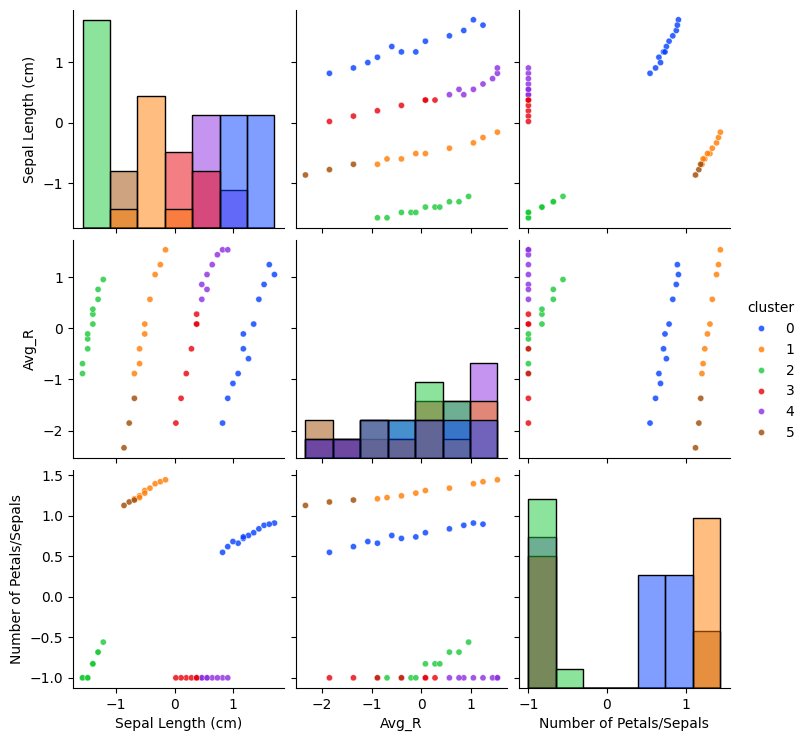

In [331]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = hier_final_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

In [332]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики 
print("Silhouette:", silhouette_score(scaled_df, hier_final_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, hier_final_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, hier_final_labels))

# Внешние метрики 
print("Adjusted Rand Index:", adjusted_rand_score(y_true, hier_final_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, hier_final_labels))

# Индекс Джакара
jaccard = jaccard_index_pairs(y_true, hier_final_labels)
print("Jaccard Index:", jaccard)

Silhouette: 0.4885898309610186
Calinski-Harabasz: 38.245994015430135
Davies-Bouldin: 0.7104249837871618
Adjusted Rand Index: 0.7932043712334924
Fowlkes-Mallows Index: 0.8460221183027866
Jaccard Index: 0.7157534246575342


Была произведена кластеризация методом GMM и на основе анализа полученных диаграмм рассеяния и метрик качества получены следующие выводы:
- По графикам рассеяния видно, что произошло четкое разбиение на кластеры в осях Sepal Length (cm) - Avg_R, Avg_R - Sepal Length (cm), Sepal Length (cm) - Number of Petals\Sepals. Но расстояния между кластерами в среднем меньше чем в GMM.
- В осях Avg_R - Number of Petals/Sepals, Number of Petals/Sepals - Avg_R имеется небольшое наложение кластеров имеется большее наложение кластеров, чем в других.
- Распределение Avg_R по кластерам лучше чем в GMM.

Внутренние метрики валидации:
- Silhouette Score = 0.488 - хорошее качество кластеризации, кластеры достаточно компактны и хорошо разделены. Немного лучше чем в GMM.
- Calinski-Harabasz = 38.25 - высокое отношение межкластерной дисперсии к внутрикластерной, кластеры плотные границы кластеров четкие.
- Davies-Bouldin = 0.71 - минимальное перекрытие между кластерами (чем ближе к 1, тем лучше)

Внешние метрики валидации:
- Adjusted Rand Index = 0.79
- Fowlkes-Mallows Index = 0.85 
- Jaccard Index = 0.72
- Около 79-85% соответствия с эталонным разбиением, присутствует некоторое перекрытие между истинными классами. Метод выявил естественную структуру данных, которая частично отличается от исходной разметки



## 4. Сравнение метрик качества для двух методов кластеризации (GMM и Иерархической)

##### Повторная иерархическая кластеризация с k=4

In [333]:
hier_4_final = AgglomerativeClustering(n_clusters=4, linkage='ward')
hier_4_final_labels = hier_4_final.fit_predict(scaled_df)

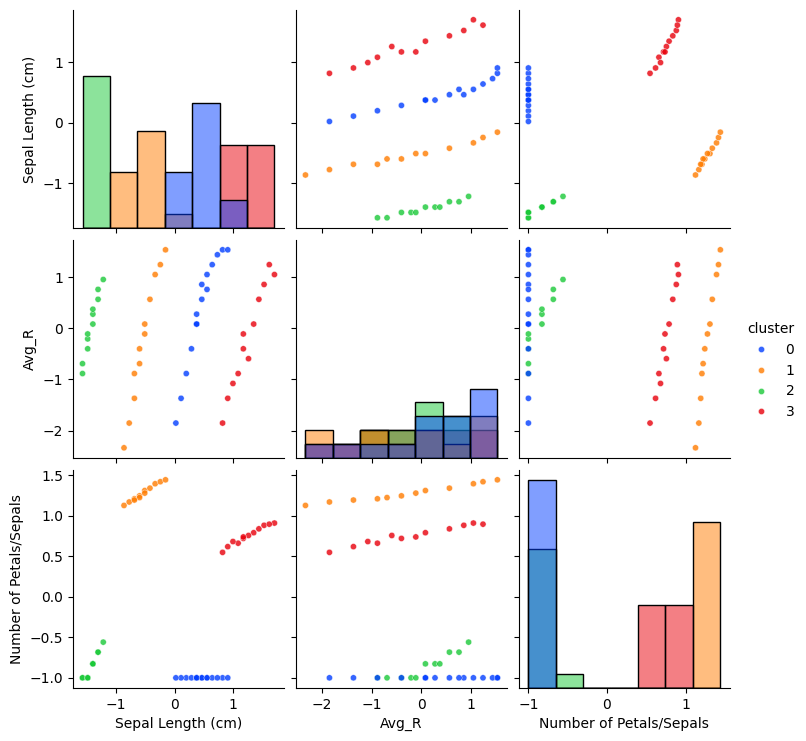

In [334]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = hier_4_final_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

In [335]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики
print("Silhouette:", silhouette_score(scaled_df, hier_4_final_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, hier_4_final_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, hier_4_final_labels))

# Внешние метрики 
print("Adjusted Rand Index:", adjusted_rand_score(y_true, hier_4_final_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, hier_4_final_labels))

# Индекс Джакара
jaccard = jaccard_index_pairs(y_true, hier_4_final_labels)
print("Jaccard Index:", jaccard)

Silhouette: 0.47232898626350867
Calinski-Harabasz: 30.77204216129424
Davies-Bouldin: 0.9021698194196958
Adjusted Rand Index: 1.0
Fowlkes-Mallows Index: 1.0
Jaccard Index: 1.0


#### Анализ внутренних и венших метрик

| Метрика                    | GMM (4 кластера)  | Иерархическая кластеризация (6 кластеров) | Иерархическая кластеризация (4 кластера) |
| -------------------------- | ----- | --------------------------- |--------------------------------------------------------------------|
| Silhouette                 | 0.472 | 0.489                       | 0.472                                                                   
| Calinski-Harabasz          | 30.77 | 38.25                       | 30.77
| Davies-Bouldin             | 0.902 | 0.710                       | 0.902
| Adjusted Rand Index (ARI)  | 1.0   | 0.793                       | 1.0
| Fowlkes-Mallows Index (FM) | 1.0   | 0.846                       | 1.0
| Jaccard Index              | 1.0   | 0.716                       | 1.0                                                                |



Иерархическая кластеризация при k=6 показала более детальное разделение на кластеры. В среднем расположение кластеров относительно друг друга уменьшилось, перекрытие ящиков с усами в большинстве случаев все также минимально, однако такая подробная кластеризация вероятно избыточна, так как особого выйгрыша она не дала и остались все те же наложения кластеров, что были в методе GMM при 4 кластерах.

Внешние метрики (Adjusted Rand Index, Fowlkes-Mallows Index): GMM демонстрирует идеальное соответствие с истинными классами (ARI = 1.0, FM = 1.0), иерархическая кластеризация показывает меньшую согласованность с истинными классами (ARI = 0.79, FM = 0.85), что указывает на частичное несовпадение кластеров с эталонными метками.

Методы оптимизируют разные критерии: GMM учитывает вероятностное распределение данных и хорошо моделирует реальные классы, а иерархическая кластеризация формирует более логичные кластеры по расстоянию, хоть они и не всегда совпадают с эталонными классами. Иерархическая кластеризация показала себя хуже, т.к. оптимальнное количество кластеров для нее не совпадает с фактической классификацией. При k=4 оба метода показывают одинаковый и правильный результат.

## 5. Влияние изменения количества кластеров k на качество GMM кластеризации

#### k=2

In [336]:
gmm_clusters = GaussianMixture(n_components=2, random_state=43)
gmm_labels = gmm_clusters.fit_predict(scaled_df)

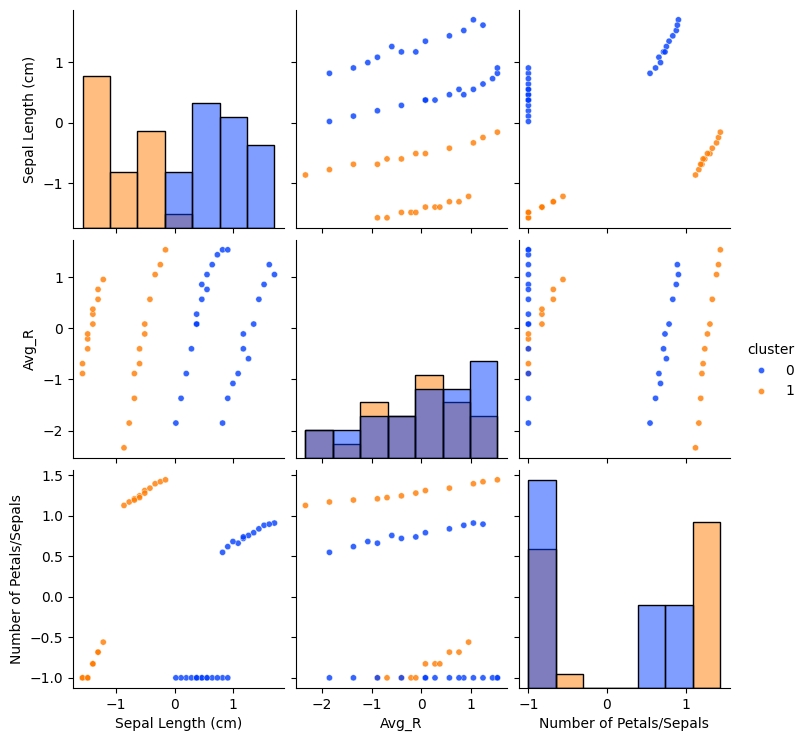

In [337]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = gmm_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

In [338]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики
print("Silhouette:", silhouette_score(scaled_df, gmm_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, gmm_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, gmm_labels))

# Внешние метрики 
print("Adjusted Rand Index:", adjusted_rand_score(y_true, gmm_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, gmm_labels))

# Индекс Джакара
jaccard = jaccard_index_pairs(y_true, gmm_labels)
print("Jaccard Index:", jaccard)

Silhouette: 0.2969538679945168
Calinski-Harabasz: 18.789219280524986
Davies-Bouldin: 1.550297699124858
Adjusted Rand Index: 0.48688619667482924
Fowlkes-Mallows Index: 0.6953011639636968
Jaccard Index: 0.48344370860927155


#### k=6

In [339]:
gmm_clusters = GaussianMixture(n_components=6, random_state=43)
gmm_labels = gmm_clusters.fit_predict(scaled_df)

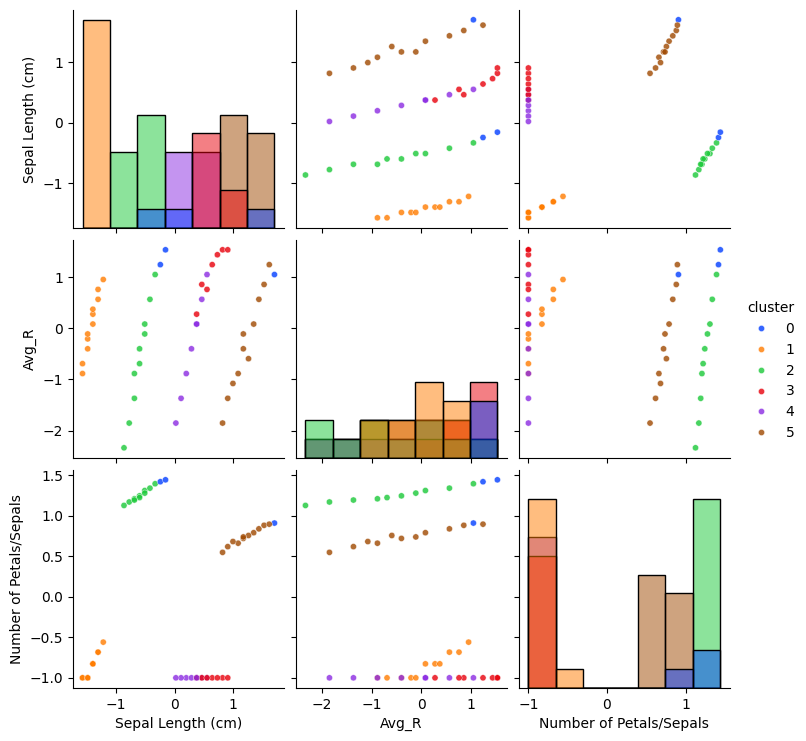

In [340]:
import seaborn as sns
import matplotlib.pyplot as plt

scaled_df_plot = scaled_df.copy()
scaled_df_plot['cluster'] = gmm_labels

sns.pairplot(scaled_df_plot, hue='cluster', diag_kind='hist', 
             plot_kws={'alpha':0.8, 's':20},
             palette='bright')
plt.show()

In [341]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, jaccard_score

# Внутренние метрики
print("Silhouette:", silhouette_score(scaled_df, gmm_labels))
print("Calinski-Harabasz:", calinski_harabasz_score(scaled_df, gmm_labels))
print("Davies-Bouldin:", davies_bouldin_score(scaled_df, gmm_labels))

# Внешние метрики 
print("Adjusted Rand Index:", adjusted_rand_score(y_true, gmm_labels))
print("Fowlkes-Mallows Index:", fowlkes_mallows_score(y_true, gmm_labels))

# Индекс Джакара
jaccard = jaccard_index_pairs(y_true, gmm_labels)
print("Jaccard Index:", jaccard)

Silhouette: 0.37260269618420544
Calinski-Harabasz: 28.293844264596167
Davies-Bouldin: 0.8526121338153144
Adjusted Rand Index: 0.777675590910852
Fowlkes-Mallows Index: 0.8338295127957743
Jaccard Index: 0.6972789115646258


#### Сравнение GMM при различных k (2, 6, 4)

| Метрика               | k = 2 | k = 6 | k = 4 |
| --------------------- | ----- | ----- | ----- |
| **Silhouette**        | 0.297 | 0.373 | 0.472 |                     
| **Calinski–Harabasz** | 18.79 | 28.29 | 30.77 |                     
| **Davies–Bouldin**    | 1.55  | 0.853 | 0.902 |                     
| **ARI**               | 0.487 | 0.778 | 1.0   |                      
| **Fowlkes–Mallows**   | 0.695 | 0.834 | 1.0   |
| **Jaccard**           | 0.483 | 0.697 | 1.0   |

При k = 2 наблюдается самое низкое качество кластеризации:

- Silhouette низкий (0.297) - слабое разделение

- CH Index минимальный - кластеры плохо разделены

- DB Index самый высокий (1.55) - сильное перекрытие кластеров

- ARI/FM/Jaccard имеют низкие значения - модель плохо воспроизводит истинные классы

При k = 6 метрики заметно улучшаются, модель начинает гораздо лучше соответствовать истинной структуре данных, хотя число кластеров явно избыточно:

- Silhouette растёт до 0.373

- Calinski–Harabasz увеличивается (28.29) - лучшее соотношение межклассовой и внутрикластерной дисперсии

- Davies-Bouldin резко уменьшается (0.853) - кластеры становятся более компактными

При k = 4 максимальное качество по всем метрикам, т.к. кластеризация полностью совпадает с изначальной классификацией.


## 6. Выводы

В результаты кластеризации цветы были поделены на условные 4 группы:


- Кластер 0 - самый низкий уровень всех признаков - примитивные/малые экземпляры. Это наиболее простые или "миниатюрные" экземпляры.
Группа однозначно выделяется в своём углу пространства признаков.

- Кластер 1 - максимальный размер и развитость - крупные/развитые экземпляры. Это самая "крупная" и развитая группа по всем параметрам.
Может указывать на экземпляры с повышенной сложностью/размерностью.

- Кластер 2 - средняя морфология - промежуточный класс. Это переходная группа средней выраженности признаков.
Она отделена от соседних групп, но с небольшим перекрытием по диапазонам.

- Кластер 3 - высокий Avg_R при умеренных других параметрах - специфическая подгруппа, отличающаяся динамическим параметром. Это группа с выраженным показателем Avg_R, но без максимальных значений остальных признаков.
Это особый подкласс, который отличается не "масштабом", а внутренним отношением параметров.